100%|██████████| 2.04G/2.04G [00:52<00:00, 41.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/balraj98/edges2shoes-dataset/versions/1
Contents: ['metadata.csv', 'train', 'val']
Train folder contents: ['10463_AB.jpg', '41362_AB.jpg', '24306_AB.jpg', '5986_AB.jpg', '15851_AB.jpg']
Using device: cuda
Total training samples: 2000
Epoch [1/10]  Loss_D: 0.2867  Loss_G: 36.7664
Epoch [2/10]  Loss_D: 0.1771  Loss_G: 23.5543
Epoch [3/10]  Loss_D: 0.4588  Loss_G: 23.1475
Epoch [4/10]  Loss_D: 0.0113  Loss_G: 42.5658
Epoch [5/10]  Loss_D: 0.0030  Loss_G: 36.1459
Epoch [6/10]  Loss_D: 0.0947  Loss_G: 35.9200
Epoch [7/10]  Loss_D: 0.0099  Loss_G: 34.1792
Epoch [8/10]  Loss_D: 0.0191  Loss_G: 28.2680
Epoch [9/10]  Loss_D: 0.0177  Loss_G: 35.3504
Epoch [10/10]  Loss_D: 0.0012  Loss_G: 42.8283


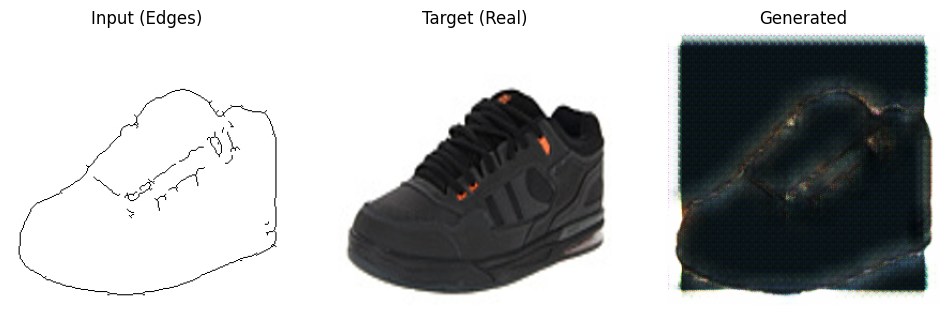

In [1]:
# -*- coding: utf-8 -*-
"""lab6.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1o5AcJ5NeJ2cBA-Hh2qkh3sLvokpSLs8D
"""

import kagglehub
path = kagglehub.dataset_download("balraj98/edges2shoes-dataset")

import os

print("Dataset path:", path)
print("Contents:", os.listdir(path))

# If train folder exists
dataset_path = os.path.join(path, "train")
print("Train folder contents:", os.listdir(dataset_path)[:5])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class Pix2PixDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = os.listdir(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        width, height = image.size

        # Left half = edges (input)
        input_image = image.crop((0, 0, width // 2, height))

        # Right half = real shoe (target)
        target_image = image.crop((width // 2, 0, width, height))

        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return input_image, target_image


transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = Pix2PixDataset(dataset_path, transform=transform)

# Use subset for faster training (optional but recommended)
dataset = torch.utils.data.Subset(dataset, range(2000))

dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Total training samples:", len(dataset))

class UNetGenerator(nn.Module):
    def __init__(self):
        super(UNetGenerator, self).__init__()

        # Encoder
        self.down1 = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        # Decoder
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)

        u1 = self.up1(d3)
        u1 = torch.cat([u1, d2], dim=1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, d1], dim=1)

        output = self.final(u2)
        return output

class PatchDiscriminator(nn.Module):
    def __init__(self):
        super(PatchDiscriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        combined = torch.cat([x, y], dim=1)
        return self.model(combined)

G = UNetGenerator().to(device)
D = PatchDiscriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 10

for epoch in range(epochs):
    for input_img, target_img in dataloader:

        input_img = input_img.to(device)
        target_img = target_img.to(device)

        # ---- Train Discriminator ----
        optimizer_D.zero_grad()

        fake_img = G(input_img)

        real_pred = D(input_img, target_img)
        fake_pred = D(input_img, fake_img.detach())

        loss_D_real = criterion_GAN(real_pred, torch.ones_like(real_pred))
        loss_D_fake = criterion_GAN(fake_pred, torch.zeros_like(fake_pred))

        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        optimizer_G.zero_grad()

        fake_pred = D(input_img, fake_img)

        loss_G_GAN = criterion_GAN(fake_pred, torch.ones_like(fake_pred))
        loss_G_L1 = criterion_L1(fake_img, target_img) * 100

        loss_G = loss_G_GAN + loss_G_L1
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

G.eval()

with torch.no_grad():
    sample_input, sample_target = next(iter(dataloader))
    sample_input = sample_input.to(device)
    generated = G(sample_input)

    input_img = sample_input[0].cpu() * 0.5 + 0.5
    target_img = sample_target[0] * 0.5 + 0.5
    fake_img = generated[0].cpu() * 0.5 + 0.5

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Input (Edges)")
    plt.imshow(np.transpose(input_img, (1,2,0)))
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Target (Real)")
    plt.imshow(np.transpose(target_img, (1,2,0)))
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Generated")
    plt.imshow(np.transpose(fake_img, (1,2,0)))
    plt.axis("off")

    plt.show()